# Colorectal Histology 2
Vou seguir o mesmo padrão do MNIST, mas com histologia colorretal. O colorectal_histology é um dataset de imagens de Classificação de texturas na histologia do câncer colorretal. Cada exemplo é uma imagem RGB de 150 x 150 x 3 de uma das 8 classes.  
No primeiro, a acurácia do treino subiu até ~87%, na validação, a acurácia se estagnou em ~31%, o que mostra um <i>overfitting</i> do modelo. Quando visualiza no sumário do modelo, mostra a possível causa, na camada `Dense(128)` depois do Flatten, tem 4.308.544 parâmetros, o que é são 99% dos parâmetros da rede neural. O Flatten produz 41.472 valores e eu conectei tudo isso em 128 neurônios sem nenhuma regularização. Também, só com 5.000 imagens, no caso, 4.000 para treino, acaba que a rede tem muitos parâmetros para poucos dados disponíveis.  
Nesta tentativa, vou adicionar um Dropout antes da Dense, vou reduzir o tamanho das imagens no pré-procesamento para 64x64 e adicionar o augmentation, para aumentar a quantidade de dados disponíveis.  
<small>**OBS:** É necessário baixar tensorflow-datasets (`pip install tensorflow-datasets`).  
Site: <https://www.tensorflow.org/datasets/catalog/colorectal_histology></small>

## Importando as bibliotecas

In [1]:
!pip install tensorflow-datasets tensorflow

In [2]:
import tensorflow as tf
import keras
import matplotlib
import numpy as np

import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import utils as np_utils
from sklearn.model_selection import train_test_split
import cv2
import matplotlib.pyplot as plt

In [3]:
# O dataset não vem dividido, então vou pegar ele e depois fazer a divisão
dataset = tfds.load('colorectal_histology', split = 'train', as_supervised = True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/colorectal_histology/incomplete.J4BJM5_2.0.0/colorectal_histology-train.tf…

Dataset colorectal_histology downloaded and prepared to /root/tensorflow_datasets/colorectal_histology/2.0.0. Subsequent calls will reuse this data.


In [4]:
# Ele tem o tamanho de 5.000 imagens pelo que eu vi no site do tensorflow
# Tambem, ele vem em uma tupla (imagem, label), vou extrair as imagens e labels em arrays separados
# depois usar o train_test_split para separar a divisão para treino e teste
imagens = np.array([
    # Fazer o redimensionamento para 64x64
    # Na aula, como ele usa de um diretório, ele usar o target_size do ImageDataGenerator
    # como estou usando o tfds, o equivalente ao target_size seria tf.image.resize
    tf.image.resize(img, (64, 64)).numpy()
    for img, label in dataset
])
labels = np.array([
    label.numpy()
    for img, label in dataset
])

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    # Divisao de 80/20, sendo 80% para treino e 20% para teste
    imagens, labels, test_size = 0.2, random_state = 42
)

In [6]:
# Diferente da aula, nao vou precisar usar o reshape
X_treino = X_treino.astype('float32')
X_teste = X_teste.astype('float32')

In [7]:
# Agora vou normalizar eles
X_treino /= 255
X_teste /= 255
X_treino.max(), X_treino.min()

(np.float32(1.0), np.float32(0.0))

In [8]:
# Vou transformar as saidas para categoricos, no codigo da aula ele usa 10, porque sao 10 classes, no meu caso sao 8 classes
y_treino = np_utils.to_categorical(y_treino , 8)
y_teste = np_utils.to_categorical(y_teste, 8)
y_treino, y_teste

(array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [1., 0., 0., ..., 0., 0., 0.]]),
 array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.]]))

In [9]:
y_treino[2]

array([0., 1., 0., 0., 0., 0., 0., 0.])

In [10]:
X_treino.shape, X_teste.shape

((4000, 64, 64, 3), (1000, 64, 64, 3))

Text(0.5, 1.0, 'Classe [0. 1. 0. 0. 0. 0. 0. 0.]')

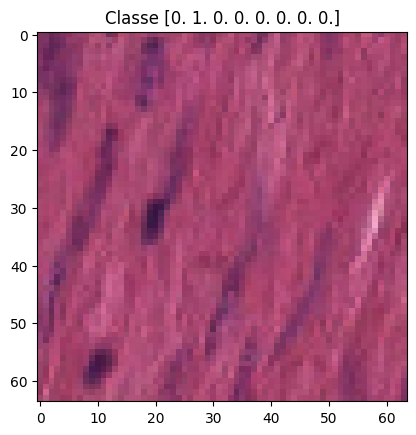

In [11]:
plt.imshow(X_treino[0])
plt.title('Classe ' + str(y_treino[0]))

In [12]:
gerador_treino = ImageDataGenerator(
    rotation_range=7,
    horizontal_flip=True,
    shear_range=0.2,
    height_shift_range=0.07,
    zoom_range=0.2
)
gerador_teste = ImageDataGenerator()

In [13]:
base_treino = gerador_treino.flow(X_treino, y_treino)
base_teste = gerador_teste.flow(X_teste, y_teste)

In [14]:
# Agora que tem os dados prontos, vou começar montar minha rede neural,
rede_neural = Sequential()

# Reduzi para 64, ja que as imagens agora tem a dimensao 64x64
rede_neural.add(InputLayer(shape =(64, 64, 3)))

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Flatten())
# Adicionei Dropout depois do Flatten
rede_neural.add(Dropout(0.5))
# Alterei o dense de 128 para 64 para reduzir os parametros
rede_neural.add(Dense(units = 64, activation = 'relu'))
rede_neural.add(Dropout(0.5))
rede_neural.add(Dense(units = 8, activation = 'softmax'))

In [15]:
rede_neural.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,392 (1.57 MB)

 Trainable params: 412,264 (1.57 MB)

 Non-trainable params: 128 (512.00 B)

In [16]:
# Agora vou compilar a rede neural
# Vou usar a função de perda categorical_crossentropy, o otimizador adam e como métrica vou usar acurácia
rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [17]:
# Finalmente, vou realizar o treino dela, vou usar 10 epocas com um batch de tamanho 128
rede_neural.fit(base_treino, epochs = 10, validation_data = (base_teste))

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.4333 - loss: 1.7556 - val_accuracy: 0.1480 - val_loss: 3.0142
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.5102 - loss: 1.2283 - val_accuracy: 0.1860 - val_loss: 3.5826
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5757 - loss: 1.0526 - val_accuracy: 0.3360 - val_loss: 2.1121
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5820 - loss: 1.0163 - val_accuracy: 0.5220 - val_loss: 1.2326
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.6195 - loss: 0.9643 - val_accuracy: 0.5250 - val_loss: 0.9889
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6428 - loss: 0.9156 - val_accuracy: 0.4370 - val_loss: 1.6128
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.6327 - loss: 0.9085 - val_accuracy: 0.4900 - val_loss: 1.2213
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6407 - loss: 0.9304 - val_acc

In [18]:
resultado = rede_neural.evaluate(X_teste, y_teste)
resultado

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3070 - loss: 5.6425


[5.642512798309326, 0.3070000112056732]